# 01 — Grid Sistemi Kurulumu

Pilot alan sınırını imar noktalarından üretip 30 m (analitik) ve 100 m (planlama) grid'lerini kurar. Her 30 m hücreye 100 m parent atar.

**Önkoşul:** `00_data_overview.ipynb` çalıştırılmış olmalı (`data/processed/imar_pilot.gpkg` mevcut).

Çıktılar:
- `data/grid/pilot_boundary.gpkg`
- `data/grid/grid_30m.gpkg`
- `data/grid/grid_100m.gpkg`
- `figures/01_grid_overview.png`
- `tables/01_grid_summary.csv`

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    DATA_PROCESSED, DATA_GRID, FIGURES, TABLES,
    CRS_PROJECTED, GRID_ANALYTIC_M, GRID_PLANNING_M,
)
from src.grid_utils import (
    build_pilot_boundary, make_grid,
    clip_grid_to_boundary, assign_parent,
)

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_GRID.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

In [ ]:
# --- Pilot noktaları yükle ---
pilot_path = DATA_PROCESSED / "imar_pilot.gpkg"
if not pilot_path.exists():
    raise FileNotFoundError(
        f"{pilot_path} yok. Önce 00_data_overview.ipynb'yi çalıştır."
    )

pilot_pts = gpd.read_file(pilot_path)
print(f"Pilot noktalar: {len(pilot_pts):,} | CRS: {pilot_pts.crs}")
print(f"\nMahalle dağılımı:\n{pilot_pts['mahalle'].value_counts()}")

Pilot noktalar: 18,575 | CRS: EPSG:32636

Mahalle dağılımı:
mahalle
HURMA             2229
LİMAN             2141
GÜRSU             1893
ALTINKUM          1390
ARAPSUYU          1370
UNCALI            1312
MOLLA YUSUF       1294
PINARBAŞI         1197
SARISU            1050
ÖĞRETMENEVLERİ    1033
TOROS              998
SİTELER            925
ULUÇ               647
KUŞKAVAĞI          551
AKKUYU             545
Name: count, dtype: int64


In [ ]:
# --- Pilot sınırı: mahalle bazlı concave hull union + buffer ---
boundary = build_pilot_boundary(
    pilot_pts,
    group_col="mahalle",
    ratio=0.3,
    buffer_m=50.0,
)

boundary_geom = boundary.geometry.iloc[0]
area_km2 = boundary_geom.area / 1e6
print(f"Pilot sınır alanı: {area_km2:.2f} km²")
print(f"Geometri tipi: {boundary_geom.geom_type}")
if boundary_geom.geom_type == "MultiPolygon":
    print(f"Parça sayısı: {len(boundary_geom.geoms)}")

boundary.to_file(DATA_GRID / "pilot_boundary.gpkg", driver="GPKG")
print(f"\nKaydedildi: {DATA_GRID / 'pilot_boundary.gpkg'}")

Pilot sınır alanı: 25.40 km²
Geometri tipi: MultiPolygon
Parça sayısı: 2

Kaydedildi: C:\Users\ercan\Desktop\AslıUTPM\data\grid\pilot_boundary.gpkg


In [ ]:
# --- 100 m grid (planlama) ---
# Önce 100m'i kur, sonra 30m'i AYNI origin ile kur — hizalı kalsınlar
import math
minx, miny, _, _ = boundary.total_bounds
origin_x = math.floor(minx / GRID_PLANNING_M) * GRID_PLANNING_M
origin_y = math.floor(miny / GRID_PLANNING_M) * GRID_PLANNING_M
print(f"Ortak origin (100m'in katı): ({origin_x:.0f}, {origin_y:.0f})")

grid_100 = make_grid(
    boundary, GRID_PLANNING_M, id_prefix="100m",
    origin=(origin_x, origin_y),
)
print(f"100m grid (kırpma öncesi): {len(grid_100):,}")

grid_100 = clip_grid_to_boundary(grid_100, boundary, method="intersects")
print(f"100m grid (kırpma sonrası): {len(grid_100):,}")

Ortak origin (100m'in katı): (283000, 4073500)


100m grid (kırpma öncesi): 11,830
100m grid (kırpma sonrası): 2,906


In [ ]:
# --- 30 m grid (analitik) ---
# Aynı origin — bu garanti: her 100m hücre tam olarak 30m'lerle hizalı değil
# (100/30 ≠ tam sayı), ama centroid bazlı parent atama sorunsuz çalışır.
grid_30 = make_grid(
    boundary, GRID_ANALYTIC_M, id_prefix="30m",
    origin=(origin_x, origin_y),
)
print(f"30m grid (kırpma öncesi): {len(grid_30):,}")

grid_30 = clip_grid_to_boundary(grid_30, boundary, method="centroid")
print(f"30m grid (kırpma sonrası): {len(grid_30):,}")

30m grid (kırpma öncesi): 129,731


30m grid (kırpma sonrası): 28,247


In [ ]:
# --- 30m hücrelere parent_id (100m) ata ---
grid_30 = assign_parent(grid_30, grid_100, parent_id_col="cell_id", out_col="parent_id")

n_orphan = grid_30["parent_id"].isna().sum()
print(f"Parent atanan: {len(grid_30) - n_orphan:,}")
print(f"Orphan (100m sınırı dışında centroid): {n_orphan:,}")

# Orphan'ları at — 100m karşılığı yoksa modelleme zincirinden çıkar
if n_orphan > 0:
    grid_30 = grid_30.dropna(subset=["parent_id"]).reset_index(drop=True)
    print(f"Orphan eleme sonrası 30m: {len(grid_30):,}")

# Her 100m altında kaç tane 30m var?
children_per_parent = grid_30.groupby("parent_id").size()
print(f"\nParent başına 30m alt-hücre — özet:")
print(children_per_parent.describe().round(1))

Parent atanan: 28,247
Orphan (100m sınırı dışında centroid): 0

Parent başına 30m alt-hücre — özet:
count    2795.0
mean       10.1
std         3.2
min         1.0
25%         9.0
50%         9.0
75%        12.0
max        16.0
dtype: float64


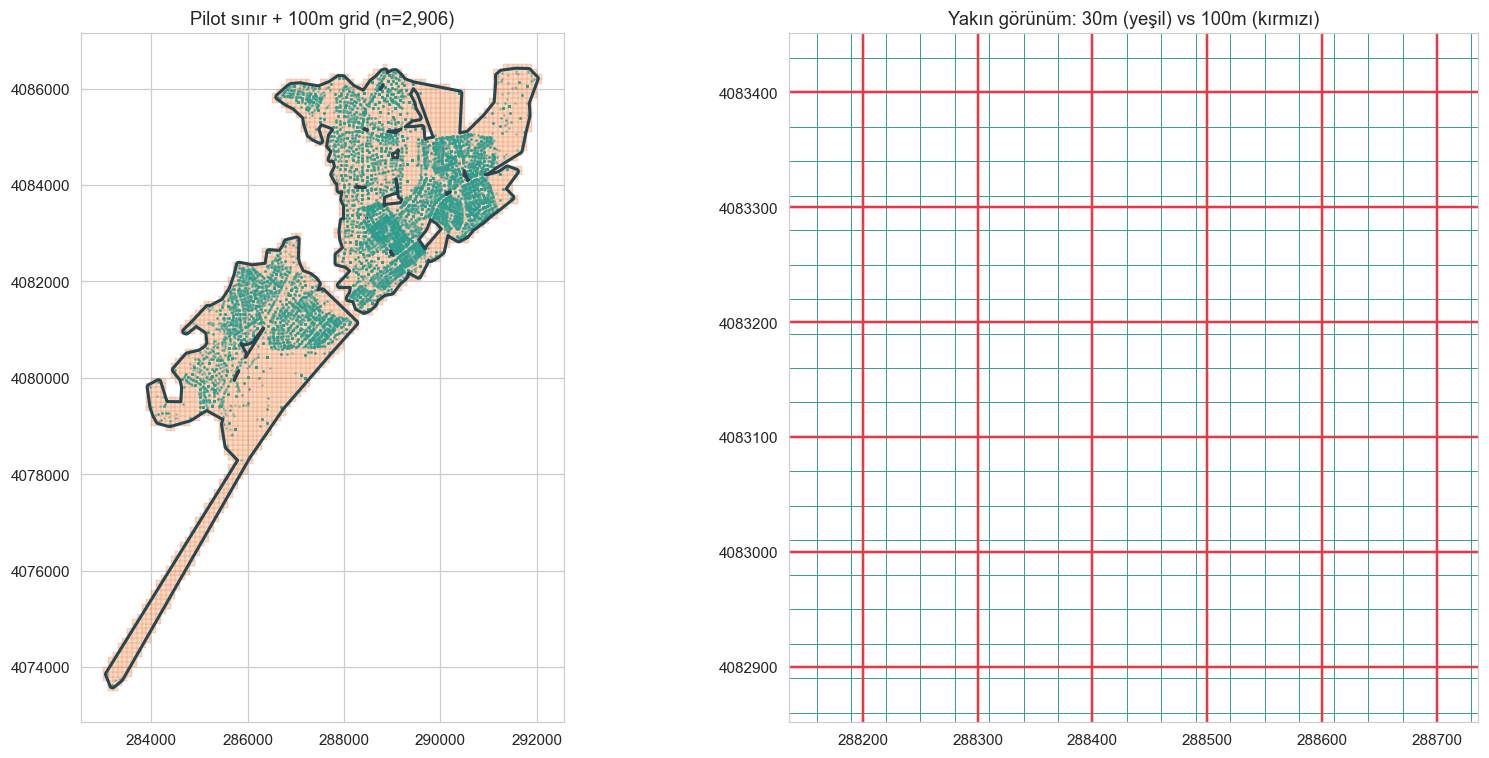

In [ ]:
# --- Görselleştirme ---
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Sol — pilot sınır + 100m grid + nokta yoğunluğu
boundary.plot(ax=axes[0], facecolor="none", edgecolor="#264653", linewidth=2, zorder=3)
grid_100.plot(ax=axes[0], facecolor="#F4A261", edgecolor="#E76F51", linewidth=0.3, alpha=0.4)
pilot_pts.plot(ax=axes[0], color="#2A9D8F", markersize=0.5, alpha=0.4, zorder=2)
axes[0].set_title(f"Pilot sınır + 100m grid (n={len(grid_100):,})")
axes[0].set_aspect("equal")
axes[0].ticklabel_format(style="plain")

# Sağ — küçük bir bbox üzerinden 30m vs 100m hizalanmasını göster
cx, cy = pilot_pts.geometry.x.mean(), pilot_pts.geometry.y.mean()
buf = 300
from shapely.geometry import box as shp_box
zoom = shp_box(cx - buf, cy - buf, cx + buf, cy + buf)
g30_zoom = grid_30[grid_30.geometry.intersects(zoom)]
g100_zoom = grid_100[grid_100.geometry.intersects(zoom)]

g30_zoom.plot(ax=axes[1], facecolor="none", edgecolor="#2A9D8F", linewidth=0.5)
g100_zoom.plot(ax=axes[1], facecolor="none", edgecolor="#E63946", linewidth=1.5)
axes[1].set_xlim(cx - buf, cx + buf)
axes[1].set_ylim(cy - buf, cy + buf)
axes[1].set_title("Yakın görünüm: 30m (yeşil) vs 100m (kırmızı)")
axes[1].set_aspect("equal")
axes[1].ticklabel_format(style="plain")

plt.tight_layout()
plt.savefig(FIGURES / "01_grid_overview.png", dpi=140, bbox_inches="tight")
plt.show()

In [ ]:
# --- Özet tablo ---
summary = pd.DataFrame({
    "metrik": [
        "pilot_alan_km2", "pilot_geom_tipi",
        "grid_30m_hucre", "grid_30m_alan_km2",
        "grid_100m_hucre", "grid_100m_alan_km2",
        "30m_per_100m_ortalama",
        "origin_x", "origin_y",
        "crs",
    ],
    "deger": [
        round(area_km2, 3),
        boundary_geom.geom_type,
        len(grid_30),
        round(len(grid_30) * (GRID_ANALYTIC_M ** 2) / 1e6, 3),
        len(grid_100),
        round(len(grid_100) * (GRID_PLANNING_M ** 2) / 1e6, 3),
        round(len(grid_30) / max(len(grid_100), 1), 2),
        int(origin_x),
        int(origin_y),
        str(grid_30.crs),
    ],
})
summary.to_csv(TABLES / "01_grid_summary.csv", index=False, encoding="utf-8-sig")
summary

,metrik,deger
0,pilot_alan_km2,25.4
1,pilot_geom_tipi,MultiPolygon
2,grid_30m_hucre,28247
3,grid_30m_alan_km2,25.422
4,grid_100m_hucre,2906
5,grid_100m_alan_km2,29.06
6,30m_per_100m_ortalama,9.72
7,origin_x,283000
8,origin_y,4073500
9,crs,EPSG:32636


In [ ]:
# --- Grid'leri kaydet ---
grid_30.to_file(DATA_GRID / "grid_30m.gpkg", driver="GPKG")
grid_100.to_file(DATA_GRID / "grid_100m.gpkg", driver="GPKG")

print("data/grid/ içeriği:")
for f in sorted(DATA_GRID.glob("*.gpkg")):
    print(f"  {f.name} — {f.stat().st_size/1024:.1f} KB")

data/grid/ içeriği:
  grid_100m.gpkg — 724.0 KB
  grid_30m.gpkg — 7048.0 KB
  pilot_boundary.gpkg — 116.0 KB


## Özet

- Pilot sınır mahalle bazlı concave hull union ile üretildi (OSM'ye bağımlı değil — sınır kalitesi noktaların kapsamına bağlı, sınırılık olarak raporlanacak).
- 30 m ve 100 m grid'leri **aynı origin** ile hizalı.
- 30 m hücrelerine centroid spatial join ile `parent_id` (100 m) bağlandı.
- Sınır dışındaki ve orphan hücreler elendi.

## Sonraki Adım

`02_lst.ipynb` — Google Earth Engine üzerinden Landsat 8/9 Collection 2 Level-2 yaz medyan kompoziti (2020–2024 Haziran–Ağustos, bulut < %10) ve grid'e zonal stat ile bağlama.